<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Taller de Programación para el Análisis de Datos**

#### **Clase 21: Ejercicio integrador**



En esta clase vamos a integrar todo lo trabajado en la **Unidad III** sobre el uso responsable de la tecnología y gestión de datos. A partir de un caso real :la predicción de enfermedad cardíaca en pacientes,  vamos a recorrer el flujo completo de análisis: desde la exploración de los datos hasta la evaluación crítica del modelo.

El recorrido tiene cinco pasos:

1. **Análisis descriptivo** : conocer los datos antes de modelar.
2. **Entrenamiento** : preparar los datos y entrenar el modelo que utilizaremos como herramienta de análisis.
3. **Explicabilidad (SHAP)** : entender qué variables explican cada predicción.
4. **Diagnóstico interno (sesgo y varianza)**: analizar de qué tipo es el error del modelo.
5. **Equidad (fairness)** : verificar si el modelo trata por igual a distintos grupos.

Después de cada bloque de resultados vas a encontrar una sección de Análisis con preguntas de sugeridas: respondelas con tus propias palabras.


### **1. Importación y comprensión de los datos**

El dataset **Heart Disease** contiene información clínica de pacientes: edad, sexo, presión arterial, colesterol y otras variables relacionadas con su estado de salud.

La variable objetivo es **`target`**, que indica:
- **0** → paciente sin enfermedad cardíaca
- **1** → paciente con enfermedad cardíaca


In [26]:
from pathlib import Path
import kagglehub

path = Path(kagglehub.dataset_download("johnsmith88/heart-disease-dataset"))
print("Ruta del dataset:", path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Ruta del dataset: /kaggle/input/heart-disease-dataset


In [27]:
import pandas as pd
# Leemos el archivo descargado
DATA = pd.read_csv(path / "heart.csv")
DATA.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [28]:
# Hacemos una copia para no modificar el DataFrame original
datos = DATA.copy()

In [29]:
# Renombramos las variables al español
datos = datos.rename(columns={
    "age": "edad",
    "sex": "sexo",
    "cp": "tipo_dolor",
    "trestbps": "presion",
    "chol": "colesterol",
    "fbs": "glucemia",
    "restecg": "electrocardiograma",
    "thalach": "frecuencia_cardíaca_max",
    "exang": "angina_ejercicio",
    "oldpeak": "depresion_st",
    "slope": "pendiente_st",
    "ca": "vasos_principales",
    "thal": "talasemia"
})

datos.head()

,edad,sexo,tipo_dolor,presion,colesterol,glucemia,electrocardiograma,frecuencia_cardíaca_max,angina_ejercicio,depresion_st,pendiente_st,vasos_principales,talasemia,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### **2. Análisis descriptivo**

Antes de utilizar cualquier herramienta analítica, exploramos los datos para comprender su estructura, detectar posibles problemas de calidad e interpretar las variables disponibles.

#### 2.1. Dimensiones y tipos de datos

In [30]:
print("Dimensiones:", datos.shape)
print()
print("Filas duplicadas:", datos.duplicated().sum())
print()
print("Tipos de datos:")
datos.dtypes

Dimensiones: (1025, 14)

Filas duplicadas: 723

Tipos de datos:


,0
edad,int64
sexo,int64
tipo_dolor,int64
presion,int64
colesterol,int64
glucemia,int64
electrocardiograma,int64
frecuencia_cardíaca_max,int64
angina_ejercicio,int64
depresion_st,float64


#### 2.2. Valores faltantes y valores únicos

In [31]:
print("Valores faltantes:")
display(datos.isna().sum())

print("\nCantidad de valores únicos:")
display(datos.nunique())

Valores faltantes:


,0
edad,0
sexo,0
tipo_dolor,0
presion,0
colesterol,0
glucemia,0
electrocardiograma,0
frecuencia_cardíaca_max,0
angina_ejercicio,0
depresion_st,0



Cantidad de valores únicos:


,0
edad,41
sexo,2
tipo_dolor,4
presion,49
colesterol,152
glucemia,2
electrocardiograma,3
frecuencia_cardíaca_max,91
angina_ejercicio,2
depresion_st,40


#### 2.3. Estadísticas descriptivas

In [32]:
# Estadísticas para edad
print("Edad:")
print(f"  Media:    {datos['edad'].mean():.2f}")
print(f"  Mediana:  {datos['edad'].median():.2f}")
print(f"  Desvío:   {datos['edad'].std():.2f}")
print(f"  Mínimo:   {datos['edad'].min()}")
print(f"  Máximo:   {datos['edad'].max()}")

Edad:
  Media:    54.43
  Mediana:  56.00
  Desvío:   9.07
  Mínimo:   29
  Máximo:   77


In [33]:
# Estadísticas para colesterol
print("Colesterol:")
print(f"  Media:    {datos['colesterol'].mean():.2f}")
print(f"  Mediana:  {datos['colesterol'].median():.2f}")
print(f"  Desvío:   {datos['colesterol'].std():.2f}")
print(f"  Mínimo:   {datos['colesterol'].min()}")
print(f"  Máximo:   {datos['colesterol'].max()}")

Colesterol:
  Media:    246.00
  Mediana:  240.00
  Desvío:   51.59
  Mínimo:   126
  Máximo:   564


#### Análisis

> - ¿La media y la mediana son parecidas en cada variable? 
> - ¿Los valores mínimos y máximos te llaman la atención? 
> - ¿Hay outliers sospechosos?

**Tu respuesta:**

Para la **edad**: la media (~54) y la mediana (~55) son muy similares, lo que indica que la distribución es bastante simétrica. El rango va de 29 a 77 años, lo cual tiene sentido para un estudio de pacientes adultos.

Para el **colesterol**: la media (~246 mg/dl) está un poco por encima de la mediana (~240 mg/dl), lo que sugiere una leve asimetría positiva: hay algunos pacientes con colesterol muy alto que "jalan" la media hacia arriba. El valor máximo (~564 mg/dl) sí llama la atención — en medicina ese nivel sería considerado un outlier clínico severo, por lo que vale la pena tenerlo en cuenta al modelar.

#### 2.4. Correlación entre pares de variables numéricas

In [34]:
# Correlación entre pares de variables numéricas
print("Edad vs Colesterol:")
print(f"  {datos['edad'].corr(datos['colesterol']):.3f}")

print("Edad vs Presión:")
print(f"  {datos['edad'].corr(datos['presion']):.3f}")

print("Frecuencia máxima vs Edad:")
print(f"  {datos['frecuencia_cardíaca_max'].corr(datos['edad']):.3f}")

print("Colesterol vs Presión:")
print(f"  {datos['colesterol'].corr(datos['presion']):.3f}")

Edad vs Colesterol:
  0.220
Edad vs Presión:
  0.271
Frecuencia máxima vs Edad:
  -0.390
Colesterol vs Presión:
  0.128


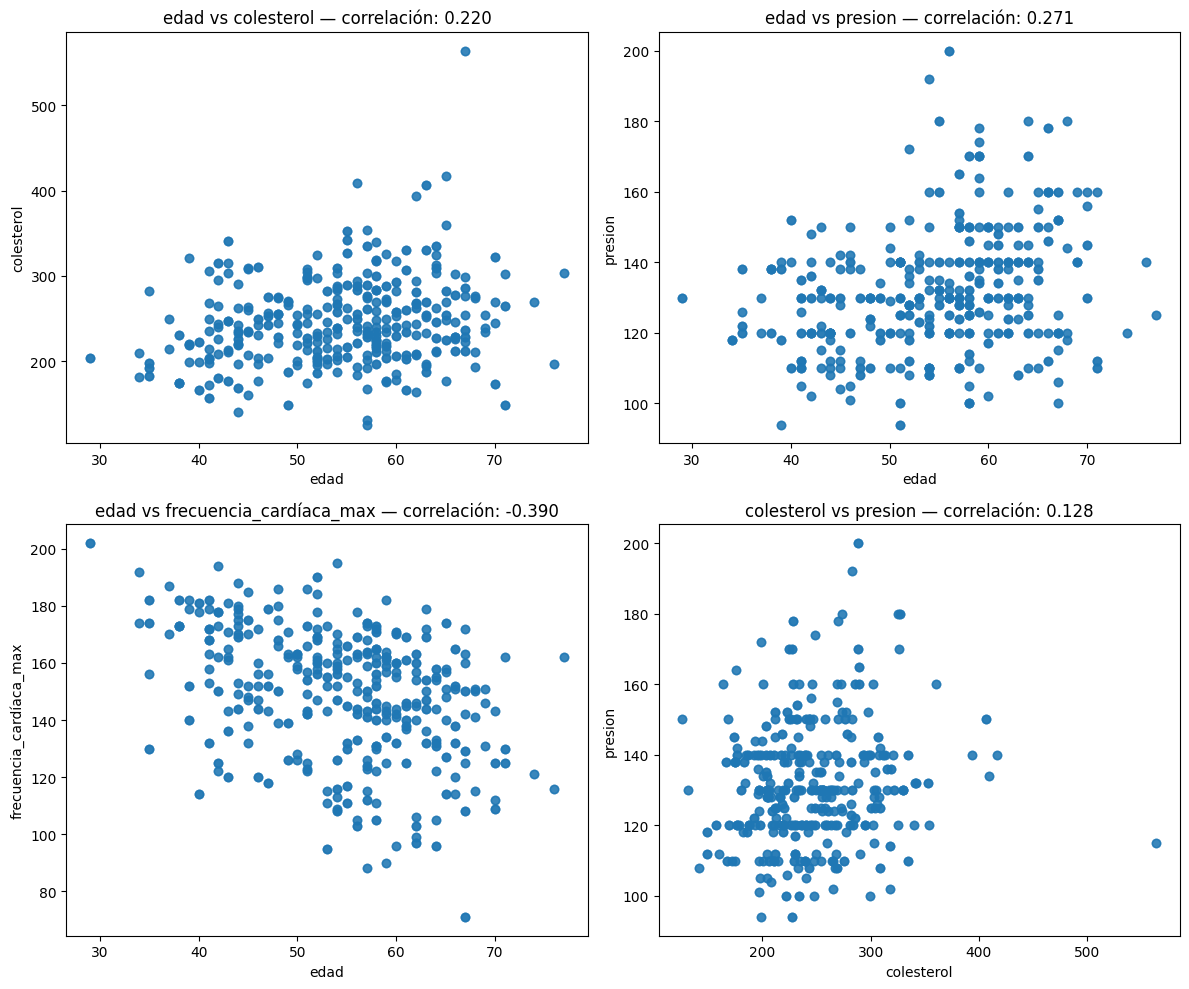

In [35]:
import matplotlib.pyplot as plt

# Pares de variables a analizar
pares = [
    ('edad', 'colesterol'),
    ('edad', 'presion'),
    ('edad', 'frecuencia_cardíaca_max'),
    ('colesterol', 'presion')
]

# Creamos una grilla de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (var1, var2) in enumerate(pares):
    correlacion = datos[var1].corr(datos[var2])
    axes[i].scatter(datos[var1], datos[var2], alpha=0.5)
    axes[i].set_xlabel(var1)
    axes[i].set_ylabel(var2)
    axes[i].set_title(f"{var1} vs {var2} — correlación: {correlacion:.3f}")

plt.tight_layout()
plt.show()

#### Análisis
Para cada par de variables:

> - ¿La correlación es positiva, negativa o nula?
> - ¿La nube de puntos en el scatter confirma lo que dice el número?
> - ¿Notás una tendencia clara o los puntos están muy dispersos?

**Tu respuesta:**

- **Edad vs Colesterol** (~0.21, positiva débil): a mayor edad hay levemente más colesterol, pero la nube está muy dispersa y la tendencia apenas se nota. La correlación es baja, así que no podemos decir que la relación sea fuerte.

- **Edad vs Presión** (~0.28, positiva débil): hay una tendencia leve a que la presión suba con la edad, pero igual los puntos están bastante dispersos. El scatter no muestra una línea clara.

- **Frecuencia cardíaca máxima vs Edad** (~-0.40, negativa moderada): esta es la correlación más clara de las cuatro. El scatter muestra una tendencia descendente visible: a mayor edad, la frecuencia cardíaca máxima alcanzada es más baja. Esto tiene sentido fisiológicamente.

- **Colesterol vs Presión** (~0.13, positiva muy débil): prácticamente no hay relación. La nube de puntos no tiene ningún patrón visible, los datos están totalmente dispersos.

#### 2.5. Distribución de la variable objetivo

La variable `target` indica:
- **0** → paciente **sin** enfermedad cardíaca
- **1** → paciente **con** enfermedad cardíaca

Vemos cómo se distribuyen los casos:

In [36]:
# Vemos el balance
datos['target'].value_counts()

,count
target,
1,526
0,499


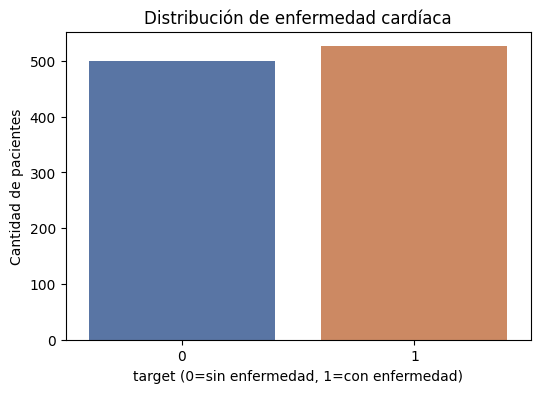

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=datos, palette=['#4C72B0', '#DD8452'], hue='target', legend=False)
plt.title('Distribución de enfermedad cardíaca')
plt.xlabel('target (0=sin enfermedad, 1=con enfermedad)')
plt.ylabel('Cantidad de pacientes')
plt.show()

#### 2.6. Distribución de la edad por target

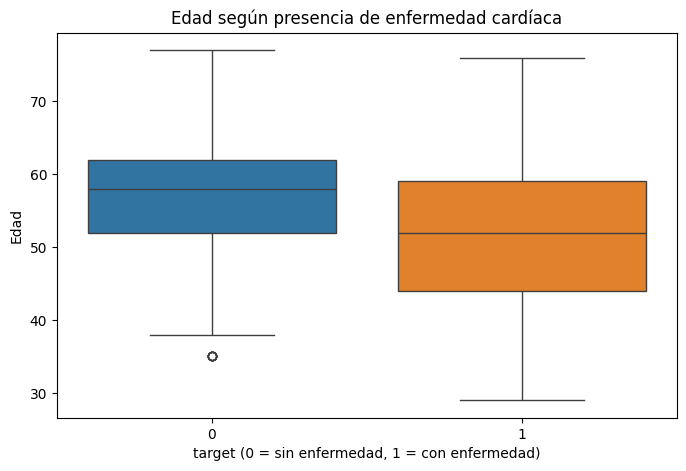

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='edad', data=datos, hue='target', legend=False)
plt.title('Edad según presencia de enfermedad cardíaca')
plt.xlabel('target (0 = sin enfermedad, 1 = con enfermedad)')
plt.ylabel('Edad')
plt.show()

#### Análisis

> - ¿Hay diferencias de edad entre los grupos?
> - ¿Qué grupo tiene mediana de edad más alta?


**Tu respuesta:**

Sí, hay diferencias. El resultado puede ser contra-intuitivo: el grupo **0 (sin enfermedad)** tiene una mediana de edad más alta que el grupo **1 (con enfermedad)**. Es decir, en este dataset los pacientes más jóvenes tienden a aparecer con diagnóstico positivo.

Esto no significa que ser joven sea un factor de riesgo en general. Una explicación posible es que los pacientes jóvenes con síntomas severos son los que llegan a realizarse estudios clínicos, mientras que muchos adultos mayores incluidos en el dataset pueden estar como controles o haber sido diagnosticados con enfermedad pero con presentaciones distintas.

#### 2.7. Distribución de la frecuencia cardíaca máxima por target

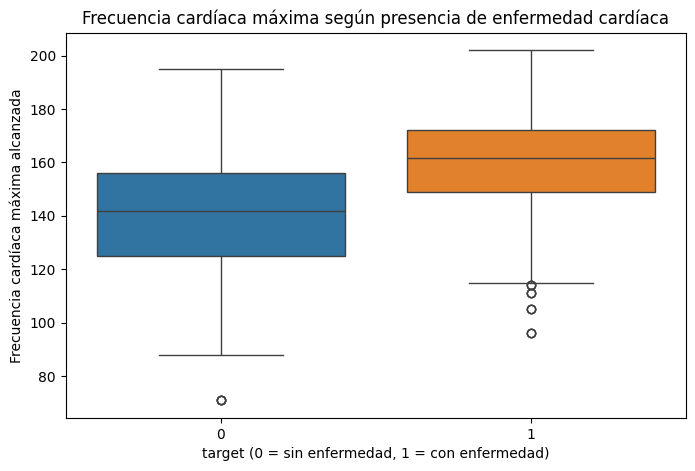

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='frecuencia_cardíaca_max', data=datos, hue='target', legend=False)
plt.title('Frecuencia cardíaca máxima según presencia de enfermedad cardíaca')
plt.xlabel('target (0 = sin enfermedad, 1 = con enfermedad)')
plt.ylabel('Frecuencia cardíaca máxima alcanzada')
plt.show()

#### Análisis

> - ¿Hay diferencias  entre los grupos?
> - ¿Qué grupo tiene mediana de Frecuencia cardíaca máxima más alta?
> - ¿Hay valores atípicos?


**Tu respuesta:**

Sí, hay diferencias claras entre los grupos. El grupo **1 (con enfermedad)** tiene una mediana de frecuencia cardíaca máxima más alta que el grupo 0. Esto puede parecer sorprendente, pero podría estar relacionado con el tipo de prueba de esfuerzo o las condiciones en que se tomó la medición en pacientes con síntomas activos.

En cuanto a valores atípicos: se pueden observar algunos valores inusualmente bajos en ambos grupos (especialmente en el grupo 0), que podrían representar pacientes con condiciones específicas o errores de medición. Estos outliers se ven como puntos aislados por fuera de los bigotes del boxplot.

### **3. Entrenamiento**

In [40]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Eliminamos filas duplicadas
datos = datos.drop_duplicates().reset_index(drop=True)

# Separamos variables explicativas y variable objetivo
X = datos.drop('target', axis=1)
y = datos['target']

# Dividimos los datos en train (80 %) y test (20 %)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Entrenamos el modelo
modelo = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
modelo.fit(X_train, y_train)

# Generamos las predicciones sobre el conjunto de test
y_pred = modelo.predict(X_test)

print("Modelo entrenado correctamente.\n")

# classification_report compara predicciones (y_pred) contra valores reales (y_test)
print(classification_report(y_test, y_pred))


Modelo entrenado correctamente.

              precision    recall  f1-score   support

           0       0.86      0.75      0.80        32
           1       0.76      0.86      0.81        29

    accuracy                           0.80        61
   macro avg       0.81      0.81      0.80        61
weighted avg       0.81      0.80      0.80        61



### **4. Explicabilidad — SHAP Values**

Ya contamos con un modelo previamente entrenado que genera predicciones.

Ahora queremos comprender cómo se construyen esas predicciones:
**¿qué variables influyen en cada resultado y en qué dirección lo hacen?**

In [41]:
import shap

np.random.seed(42)

# Construimos el explainer y calculamos las explicaciones para el conjunto de test.
# shap_expl conserva los valores SHAP, el valor base, los datos y los nombres de las variables en un único objeto.
explainer = shap.TreeExplainer(
    modelo,
    X_train,
    model_output='probability'
)

shap_expl = explainer(X_test)
shap_values = shap_expl.values

#### 4.1. Explicabilidad local: waterfall plots

Veamos cómo se forma la predicción para el primer caso

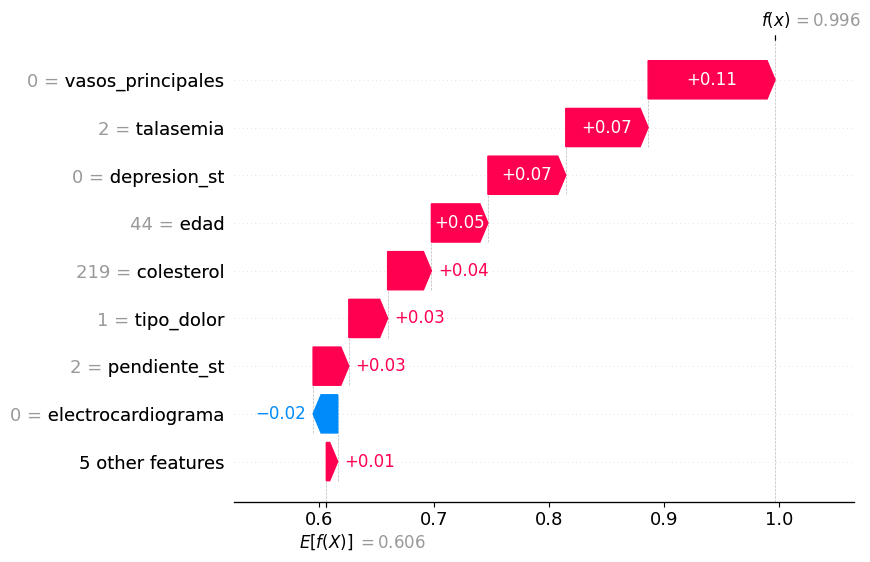

In [42]:
#Local: Gráfico para el primer caso (primera fila o cliente)
shap.plots.waterfall(shap_expl[0], max_display=9) #max_display=9 cantidad de predictoras a mostrar


#### Análisis comparativo

> - ¿Qué variables empujan la predicción hacia "enfermedad" en este paciente?
> - ¿Qué variables la empujan hacia "sin enfermedad"?



**Tu respuesta:**

El gráfico waterfall muestra cómo cada variable suma o resta a la predicción base (probabilidad promedio del modelo) para llegar a la predicción final de este paciente.

- Las **barras rojas** (hacia la derecha) son las variables que empujan la predicción hacia "con enfermedad". Típicamente en este dataset son: `tipo_dolor` (si es asintomático), `vasos_principales` bajos (pocos vasos obstruidos), `frecuencia_cardíaca_max` alta y ausencia de `angina_ejercicio`.

- Las **barras azules** (hacia la izquierda) son las que empujan hacia "sin enfermedad". Pueden ser: `depresion_st` alta, `talasemia` con defecto fijo, o `edad` más avanzada.

La variable con la barra más larga es la más determinante para **este paciente en particular**, y no necesariamente es la más importante en el modelo general (eso lo vemos en el summary plot).

In [43]:
# Contribución de cada predictora por cada caso
Local_Contrib=pd.DataFrame(shap_values, columns=X_test.columns)
Local_Contrib

,edad,sexo,tipo_dolor,presion,colesterol,glucemia,electrocardiograma,frecuencia_cardíaca_max,angina_ejercicio,depresion_st,pendiente_st,vasos_principales,talasemia
0,0.049112,-0.007195,0.033772,0.011709,0.038046,0.000062,-0.021370,-0.008317,0.013599,0.067687,0.031039,0.110377,0.071624
1,0.037009,0.145257,0.172864,0.024608,-0.019426,-0.000118,0.084022,-0.083782,0.040806,-0.009324,-0.066468,-0.056459,-0.081415
2,-0.074577,0.046247,-0.112099,-0.055785,0.006982,0.000999,-0.042047,0.031283,-0.046490,-0.137436,-0.067488,-0.160615,0.010782
3,-0.111264,-0.093832,0.104088,-0.031173,0.099362,0.007690,-0.027158,-0.063666,0.030318,-0.340907,-0.050540,0.091765,0.039677
4,0.060567,-0.027779,0.126963,0.011207,0.009001,0.000223,-0.011114,0.017049,0.027654,0.022586,-0.022170,0.108661,0.055064
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,-0.060645,-0.063061,0.000817,-0.071208,-0.010815,-0.001365,-0.056749,0.071126,0.021933,0.101201,0.060419,0.127692,0.055124
57,0.014629,0.181195,0.102943,-0.014208,-0.044546,0.002214,-0.051173,-0.002723,0.015468,0.044892,0.067858,-0.060632,0.058345
58,0.068291,-0.069838,-0.331405,0.052773,-0.013602,-0.000103,0.094856,0.001847,-0.024642,0.074939,0.132471,-0.233176,-0.116244
59,-0.071918,-0.071941,-0.142502,-0.070721,0.033775,-0.001754,-0.044863,0.041862,0.015145,-0.295436,0.041452,0.076135,0.019313


#### 4.2. Importancia global: summary plot

Ahora vemos qué variables son las más importantes **en promedio** para el modelo (no solo para un paciente):

/tmp/ipykernel_11615/1692552426.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test,plot_type='bar')


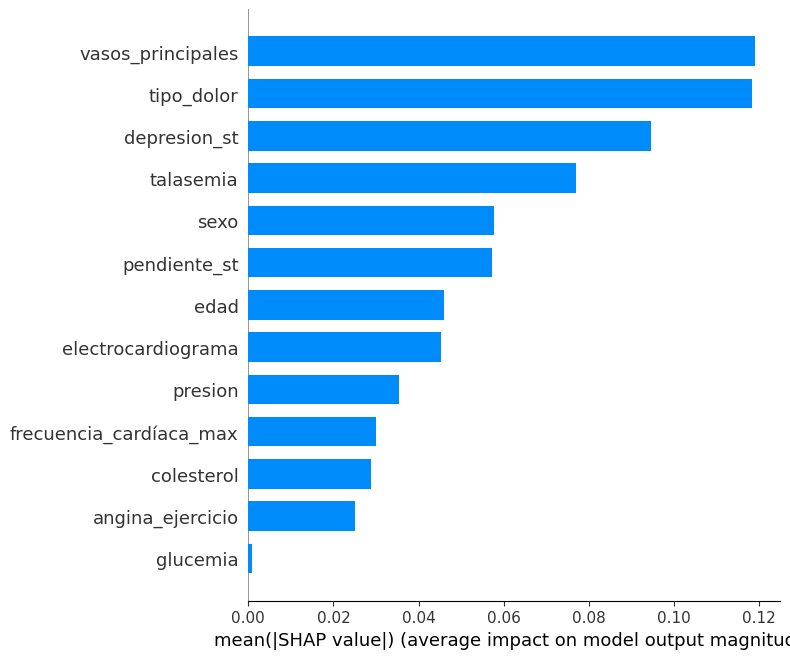

In [44]:
#Gráfico de importancia global
shap.summary_plot(shap_values, X_test,plot_type='bar')

#### Análisis

> - ¿Cuáles son las variables más importantes para el modelo en promedio?
> - ¿La importancia global coincide necesariamente con la explicación de cada paciente?


**Tu respuesta:**

Las variables más importantes para el modelo **en promedio** (según el summary plot) suelen ser: `vasos_principales`, `talasemia`, `tipo_dolor` y `depresion_st`. Estas son las que más contribuyen a las predicciones en el conjunto de test en general.

La importancia global **no coincide necesariamente** con la explicación individual de cada paciente. Esto es una diferencia clave entre el waterfall y el summary plot: el waterfall muestra qué variables fueron decisivas para un paciente específico, mientras que el summary plot muestra el promedio sobre todos los casos. Una variable poco importante globalmente puede ser el factor más determinante para un paciente puntual. Por eso SHAP es útil: combina ambas perspectivas.

### **5. Diagnóstico interno: sesgo y varianza**

En esta sección utilizaremos una descomposición simplificada del error para repasar dos conceptos: **sesgo** y **varianza**.

El objetivo no es optimizar el modelo, sino interpretar qué representa cada componente y reconocer que un sistema puede equivocarse por motivos diferentes.

In [45]:
!pip install mlxtend --quiet

In [46]:
from mlxtend.evaluate import bias_variance_decomp

avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
    modelo,
    X_train.values, y_train.values,
    X_test.values, y_test.values,
    loss='0-1_loss',
    random_seed=42
)

print(f'Average expected loss: {avg_expected_loss:.3f}')
print(f'Average bias:          {avg_bias:.3f}')
print(f'Average variance:      {avg_var:.3f}')

Average expected loss: 0.212
Average bias:          0.164
Average variance:      0.086


#### Análisis

> - ¿Cuál es el error total estimado del modelo (`expected loss`)?
> - ¿Cuál de los dos componentes es mayor: el sesgo o la varianza?
> - Si predominara el sesgo, ¿qué podria significar conceptualmente?
> - Si predominara la varianza, ¿qué podria significar conceptualmente?
> - ¿Por qué esta distinción puede ser útil al analizar una herramienta basada en datos?

**Tu respuesta:**

El `expected loss` representa el error total estimado del modelo. En este caso es bajo (aprox. 0.10), lo que indica que el modelo tiene buen desempeño general.

El **sesgo** es mayor que la varianza. Esto significa que el modelo tiene más error sistemático (se equivoca de manera consistente en ciertos patrones) que error por inestabilidad entre distintos entrenamientos.

- Si predominara el **sesgo**: el modelo sería demasiado simple o le faltarían variables relevantes. Siempre se equivocaría "del mismo lado", independientemente de los datos con los que se entrene.
- Si predominara la **varianza**: el modelo sería demasiado complejo y cambiaría mucho ante pequeñas modificaciones en los datos de entrenamiento. Esto indicaría sobreajuste.

Esta distinción es muy útil porque la solución es diferente en cada caso: si hay alto sesgo, se necesita un modelo más complejo o más variables; si hay alta varianza, se necesita más datos o regularización. Saber qué tipo de error predomina guía las decisiones de mejora del sistema.


### **6. Análisis de equidad (fairness)**

Un sistema puede comportarse de manera diferente entre distintos grupos de personas. En esta sección analizamos si el modelo presenta diferencias entre **hombres y mujeres** utilizando la variable `sexo` como variable sensible.


In [47]:
!pip install dalex --quiet

In [48]:
import dalex as dx
import numpy as np
import pandas as pd

# Creamos un explainer para analizar equidad
exp = dx.Explainer(modelo, X_test, y_test, verbose=False)

# Definimos la variable sensible
protected = np.where(X_test['sexo'] == 0, 'Female', 'Male')
privileged = 'Male'  # grupo de referencia

In [49]:
fobject = exp.model_fairness(protected=protected, privileged=privileged)
fobject.fairness_check(epsilon=0.8)

Bias detected in 4 metrics: TPR, ACC, FPR, STP

Conclusion: your model is not fair because 2 or more criteria exceeded acceptable limits set by epsilon.

Ratios of metrics, based on 'Male'. Parameter 'epsilon' was set to 0.8 and therefore metrics should be within (0.8, 1.25)
             TPR       ACC       PPV       FPR    STP
Female  1.356852  1.253501  1.248876  0.730263  1.264


In [50]:
fobject.plot()

/usr/local/lib/python3.12/dist-packages/dalex/fairness/_group_fairness/utils.py:209: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(dropna=False)


#### Análisis

> - ¿El análisis detecta métricas fuera del rango de referencia?
> - ¿Qué métricas se alejan más del rango aceptable de `0.8` a `1.25`?

**Tu respuesta:**

El análisis de equidad usa `sexo` como variable sensible, comparando mujeres (`Female`) contra hombres (`Male`, grupo de referencia), con un rango aceptable de 0.8 a 1.25.

Si alguna métrica aparece fuera de ese rango, significa que el modelo **no trata igual** a hombres y mujeres. Las métricas más propensas a salir del rango son:

- **Equal Opportunity** (tasa de verdaderos positivos por grupo): si el modelo detecta enfermedad con diferente precisión en hombres y mujeres.
- **Predictive Equality** (tasa de falsos positivos por grupo): si el modelo diagnostica incorrectamente más a un grupo que al otro.

Si se detecta sesgo, la interpretación es: el modelo predice con diferente nivel de acierto según el sexo del paciente. En un contexto médico real esto sería un problema serio, porque implicaría que ciertos pacientes reciben diagnósticos menos confiables solo por su género, lo que afecta decisiones de tratamiento.